In [82]:
import pandas as pd
import numpy as np
import re
import json
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, cross_val_predict
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from scipy.stats import entropy
import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
pd.set_option('display.max_columns', None)
np.set_printoptions(suppress=True)

data= pd.read_csv("anti_total.csv".strip('\u202a'), index_col=False)
# data= pd.read_csv(r"‪D:\ML Data\Spesis\anti_total.csv".strip('\u202a'), index_col=False)

In [84]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [85]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [86]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [87]:
final_cols = col_sum[col_sum >= 10].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [88]:
data_filter[final_cols].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid            5515.0
Flomoxef                               5196.0
Cefazolin                              2371.0
Cefixime                               2166.0
Ciprofloxacin                          2071.0
Azithromycin                           2053.0
Cefuroxime                             1691.0
Piperacillin/Tazobactam                1511.0
Cefoperazone/sulbactam                 1412.0
Peramivir                              1119.0
Baloxavir marboxil                     1085.0
Metronidazole                          1020.0
Cefadroxil                              918.0
Oseltamivir                             835.0
Levofloxacin                            720.0
Clindamycin                             624.0
Gentamicin                              623.0
Ceftriaxone                             610.0
Cephalexin                              517.0
Ampicillin                              423.0
Amoxicillin                             388.0
Doxycycline                       

In [89]:
len(data_filter), len(data_filter['ACCOUNTNO'])

(27968, 27968)

In [90]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9'
]

temp_site = data_filter[all_site_cols].copy()

# robust cleaning（避免奇怪值）
temp_site = (
    temp_site.astype(str)
    .apply(lambda x: x.str.strip())
    .replace(['', 'nan', 'None', 'nan.0'], '0')
    .astype(float)
)

# 建 flag
data_filter = data_filter.copy()
data_filter['Miss_INFECTSITE_flag'] = (temp_site == 0).all(axis=1).astype(int)

In [91]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
data_filter = data_filter.copy()
data_filter['ROOMNO'] = data_filter['ROOMNO'].map(roomno_mapping)          

data_filter['SEX'] = data_filter['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    data_filter[col] = data_filter[col].map({'Y': 1, 'N': 0})

In [92]:
feature_cols = list(set(data_filter.columns) - set(abx_cols))
X = data_filter[feature_cols]
y = data_filter[final_cols]

In [93]:
X.shape, y.shape

((27968, 70), (27968, 47))

In [94]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0', 'Bacteria level', 'MAP'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir'])#, 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [1]:
# 在 drop 欄位後，先強迫 X 和 y 的索引同步
# 確保兩者擁有完全一樣的病患 ID (Index)
common_idx = X.index.intersection(y.index)
X = X.loc[common_idx]
y = y.loc[common_idx]

# 找出至少有一種藥物的樣本 (Row sum > 0)
has_label_mask = (y.sum(axis=1) > 0)

# 同步過濾 X 和 y
X = X.loc[has_label_mask]
y = y.loc[has_label_mask]

print(f"原本樣本數: {len(has_label_mask)}")
print(f"過濾後樣本數: {len(y)}")
print(f"已刪除 {len(has_label_mask) - len(y)} 筆因刪除藥物欄位而變成『無給藥』的樣本")

NameError: name 'X' is not defined

In [96]:
X.columns

Index(['PT', 'Ht', 'Na', 'CNS', 'Neutrophil Seg.', 'AUTOIMMUNE',
       'Absolute Neutrophil count', 'Creatinine', 'CHECKITEM29SCORE', 'CANCER',
       'RBC', 'CHECKITEM28SCORE', 'Microscopic WBC level', 'CRP',
       'CHECKITEM30SCORE', 'HCO3', 'VITALSIGNSDBP', 'CHECKITEM27', 'SEX', 'PH',
       'CHECKITEM27SCORE', 'INFECTIONSITE9', 'FEVER', 'INFECTIONSITE2',
       'LIVER', 'VITALSIGNSSPO2', 'INJURELEVEL', 'Miss_INFECTSITE_flag',
       'INFECTIONSITE1', 'OTHERINFECTIONSITE_flag', 'VITALSIGNSPR',
       'VITALSIGNSRR', 'O2 SAT', 'Hb', 'T.Bilirubin', 'GPT',
       'Microscopic RBC level', 'APTT', 'INFECTIONSITE3', 'HST', 'Lymphocyte',
       'INFECTIONSITE4', 'PCO2', 'CHECKITEM32SCORE', 'INFECTIONSITE5', 'PLT',
       'AGE', 'KIDNEY', 'VITALSIGNSGCS', 'INR', 'DM', 'CARDIOVASCULAR',
       'BE(ecf)', 'Nitrite level', 'WBC', 'CHECKITEM31SCORE', 'K',
       'StayTime_hours', 'CHECKITEM28A', 'VITALSIGNSBT', 'RESPIRATORY',
       'Leukocyte level'],
      dtype='object')

In [97]:
y[y.columns].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid            5515.0
Flomoxef                               5196.0
Cefazolin                              2371.0
Cefixime                               2166.0
Ciprofloxacin                          2071.0
Azithromycin                           2053.0
Cefuroxime                             1691.0
Piperacillin/Tazobactam                1511.0
Cefoperazone/sulbactam                 1412.0
Metronidazole                          1020.0
Cefadroxil                              918.0
Levofloxacin                            720.0
Clindamycin                             624.0
Gentamicin                              623.0
Ceftriaxone                             610.0
Cephalexin                              517.0
Ampicillin                              423.0
Amoxicillin                             388.0
Doxycycline                             358.0
Nemonoxacin                             169.0
Acyclovir                               157.0
Valaciclovir                      

In [98]:
####################### Missing 20~60% #######################

# 檢驗

X['VITALSIGNSSPO2_flag'] = (
     X['VITALSIGNSSPO2'].fillna('').str.strip().ne('').astype(int))

X['Hb_flag'] = (
     X['Hb'].fillna('').str.strip().ne('').astype(int))

X['WBC_flag'] = (
     X['WBC'].fillna('').str.strip().ne('').astype(int))

X['Ht_flag'] = (
     X['Ht'].fillna('').str.strip().ne('').astype(int))

X['PLT_flag'] = (
     X['PLT'].fillna('').str.strip().ne('').astype(int))

X['Lymphocyte_flag'] = (
     X['Lymphocyte'].fillna('').str.strip().ne('').astype(int))

X['Neutrophil Seg._flag'] = (
     X['Neutrophil Seg.'].fillna('').str.strip().ne('').astype(int))

X['Absolute Neutrophil count_flag'] = (
     X['Absolute Neutrophil count'].fillna('').str.strip().ne('').astype(int))

X['Na_flag'] = (
     X['Na'].fillna('').str.strip().ne('').astype(int))

X['K_flag'] = (
     X['K'].fillna('').str.strip().ne('').astype(int))

X['PLT_flag'] = (
     X['PLT'].fillna('').str.strip().ne('').astype(int))

X['Creatinine_flag'] = (
     X['Creatinine'].fillna('').str.strip().ne('').astype(int))

X['GPT_flag'] = (
     X['GPT'].fillna('').str.strip().ne('').astype(int))

X['CRP_flag'] = (
     X['CRP'].fillna('').str.strip().ne('').astype(int))

# 計分

####################### Missing 70~80% #######################

# 檢驗

X['Leukocyte level_flag'] = (
     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

X['Nitrite level_flag'] = (
     X['Nitrite level'].fillna('').str.strip().ne('').astype(int))


X['Microscopic RBC level_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic WBC level_flag'] = (
     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

X['PH_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# 計分

X['CHECKITEM29SCORE_flag'] = (
     X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM30SCORE_flag'] = (
     X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


####################### Missing > 80% #######################

# 檢驗

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['T.Bilirubin_flag'] = (
     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

X['PT_flag'] = (
     X['PT'].fillna('').str.strip().ne('').astype(int))

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['INR_flag'] = (
     X['INR'].fillna('').str.strip().ne('').astype(int))

X['APTT_flag'] = (
     X['APTT'].fillna('').str.strip().ne('').astype(int))

X['PCO2_flag'] = (
     X['PCO2'].fillna('').str.strip().ne('').astype(int))

X['HCO3_flag'] = (
     X['HCO3'].fillna('').str.strip().ne('').astype(int))


X['BE(ecf)_flag'] = (
     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

X['O2 SAT_flag'] = (
     X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# 計分

X['CHECKITEM28A_flag'] = (
     X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27_flag'] = (
     X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27SCORE_flag'] = (
     X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM28SCORE_flag'] = (
     X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM31SCORE_flag'] = (
     X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM32SCORE_flag'] = (
     X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


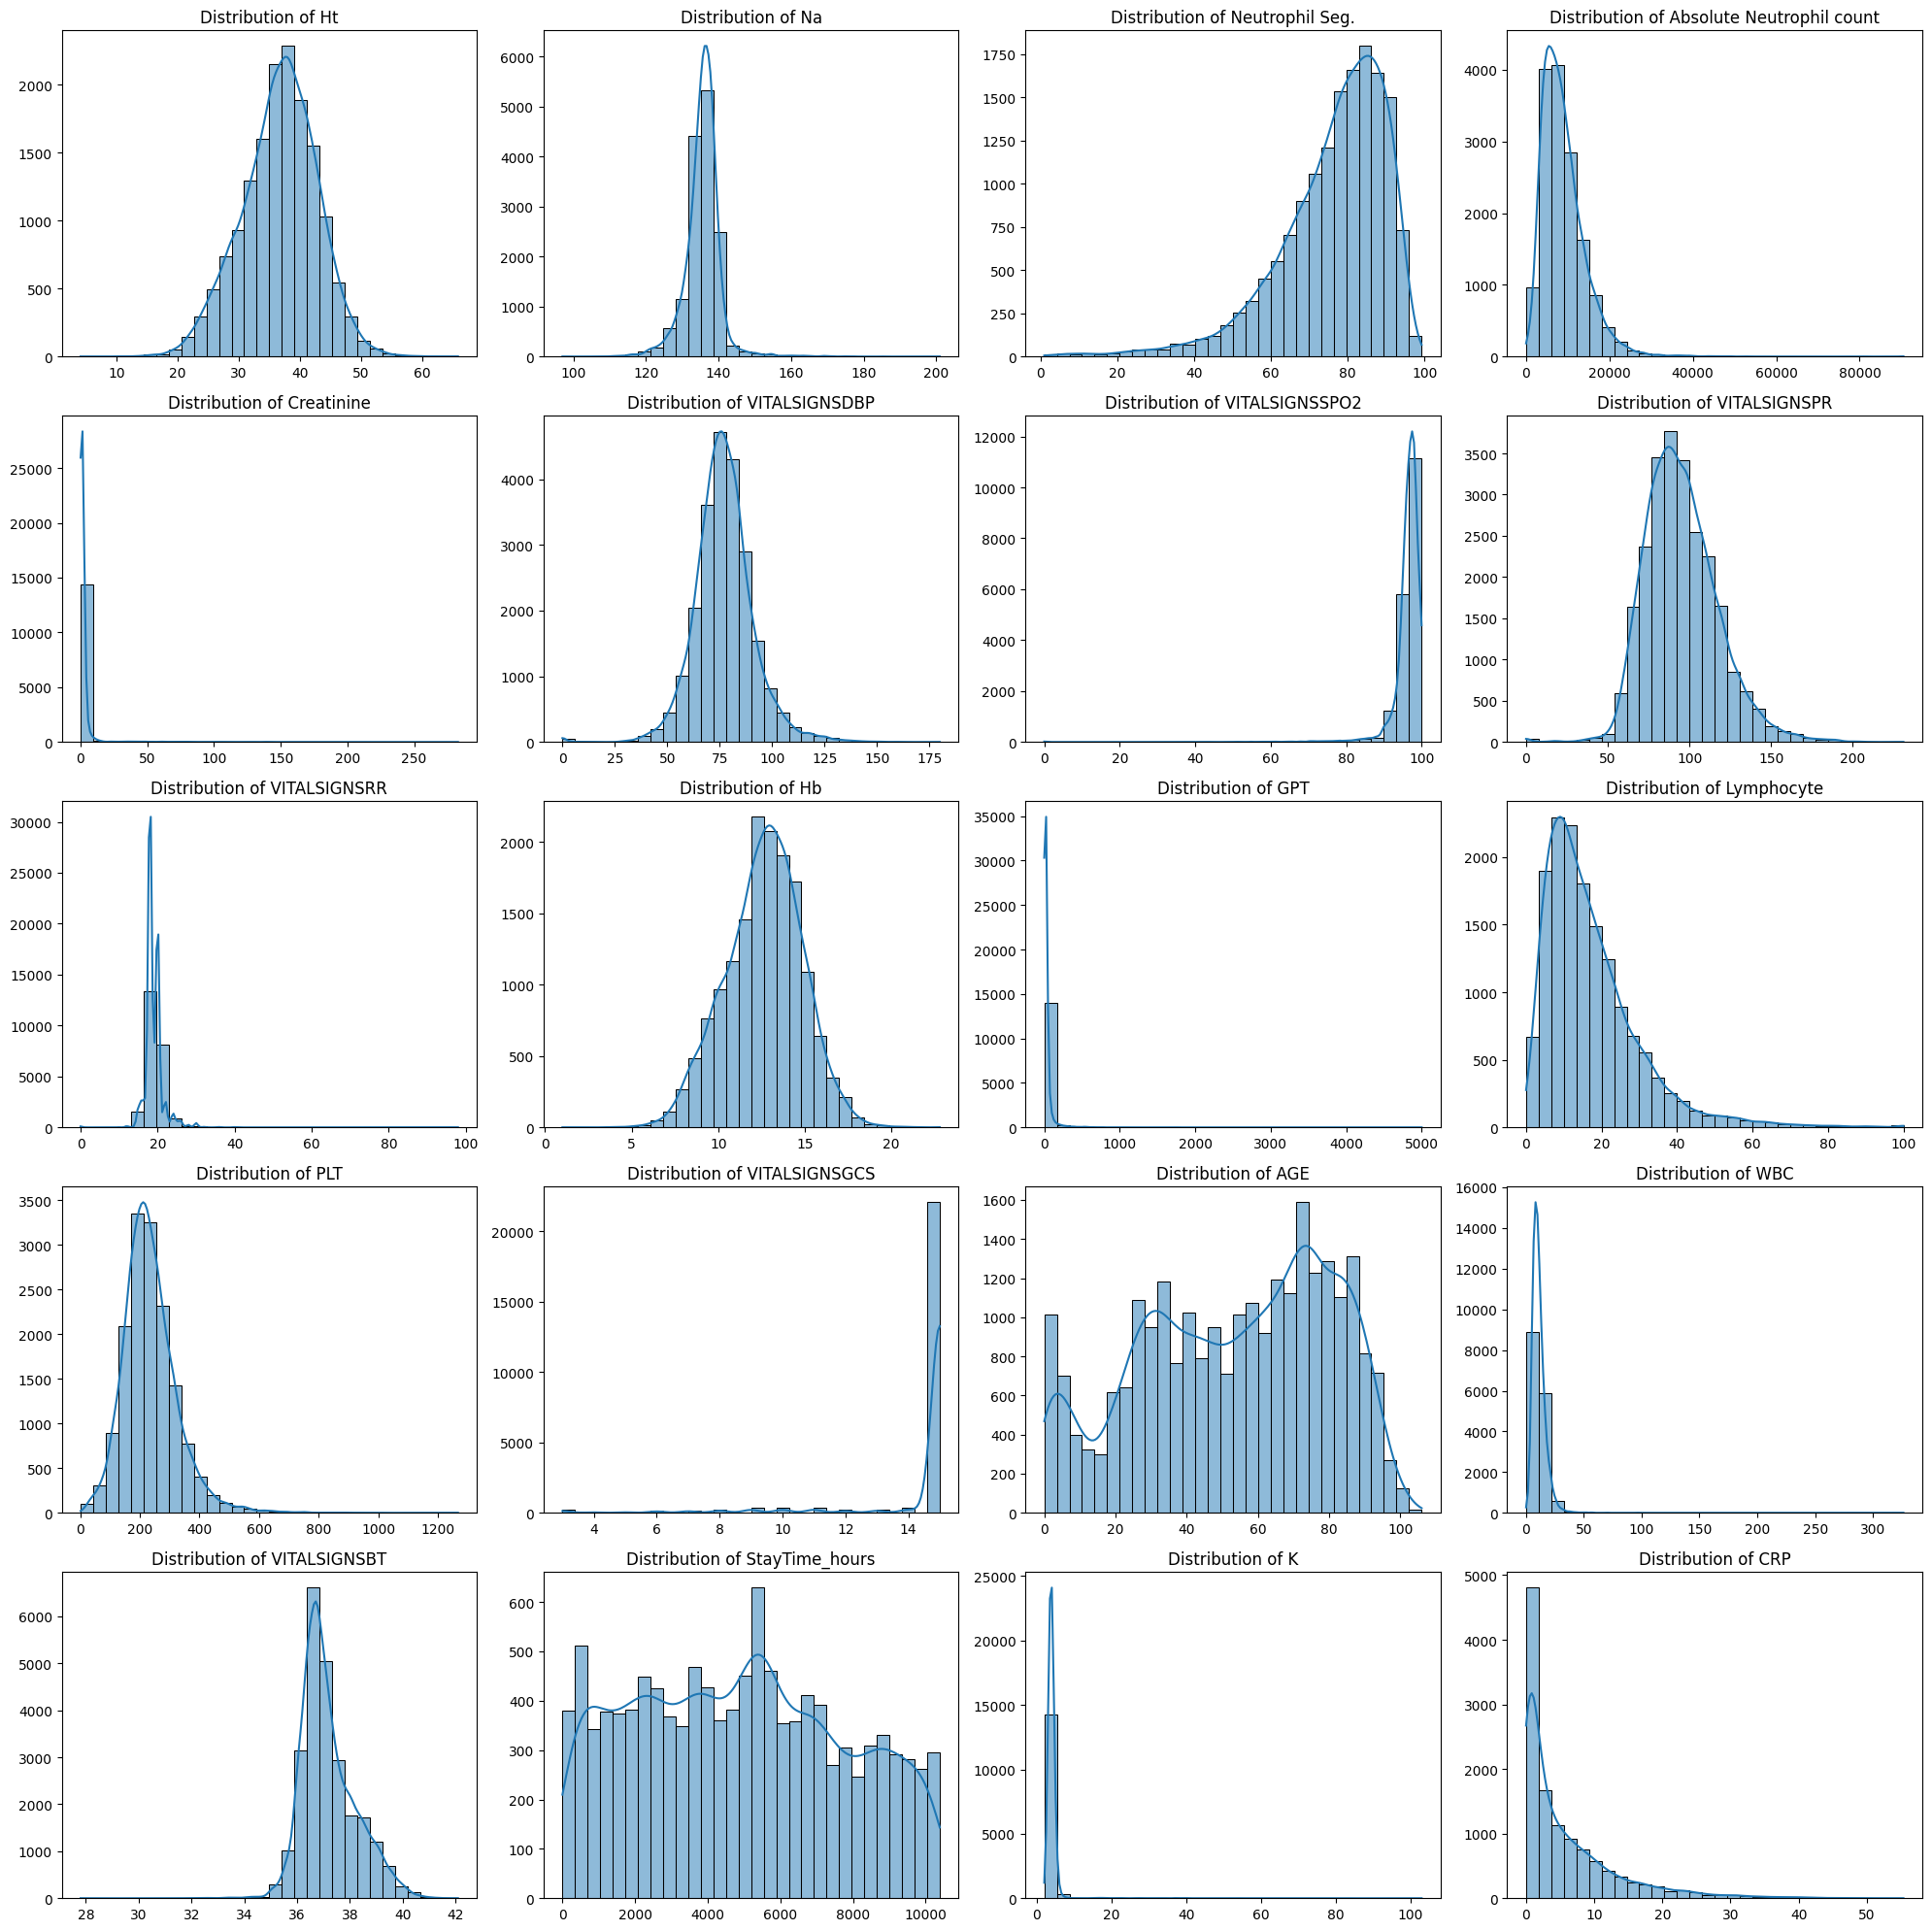

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [100]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 7410

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              237                   244   
VITALSIGNSDBP                             226                   227   
VITALSIGNSBT                              200                   207   
VITALSIGNSRR                              117                   230   
WBC                                       155                   155   
Ht                                        152                   156   
RBC                                       154                   152   
Absolute Neutrophil count                 152                   152   
PLT                                       150                   153   
Hb                                        147                   152   

                           Total_Outliers  
VITALSIGNSPR                          481  
VITALSIGNSDBP                         453  
VITALSIGNSBT                          407  
VITAL

In [101]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((20192, 97), (20192, 44), (5048, 97), (5048, 44))

In [103]:
# 對齊index

X_train = X_train.copy()
y_train = y_train.copy()

X_test = X_test.copy()
y_test = y_test.copy()

X_train.index = range(len(X_train))
y_train.index = range(len(y_train))

X_test.index = range(len(X_test))
y_test.index = range(len(y_test))

In [104]:
X_train.isnull().sum(), X_test.isnull().sum()

(PT                       15958
 Ht                        7764
 Na                        8360
 CNS                          0
 Neutrophil Seg.           8046
                          ...  
 CHECKITEM27_flag             0
 CHECKITEM27SCORE_flag        0
 CHECKITEM28SCORE_flag        0
 CHECKITEM31SCORE_flag        0
 CHECKITEM32SCORE_flag        0
 Length: 97, dtype: int64,
 PT                       3985
 Ht                       1916
 Na                       2064
 CNS                         0
 Neutrophil Seg.          1990
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 97, dtype: int64)

In [105]:
X_train.dtypes, X_test.dtypes

(PT                       float64
 Ht                       float64
 Na                       float64
 CNS                        int64
 Neutrophil Seg.          float64
                           ...   
 CHECKITEM27_flag           int32
 CHECKITEM27SCORE_flag      int32
 CHECKITEM28SCORE_flag      int32
 CHECKITEM31SCORE_flag      int32
 CHECKITEM32SCORE_flag      int32
 Length: 97, dtype: object,
 PT                       float64
 Ht                       float64
 Na                       float64
 CNS                        int64
 Neutrophil Seg.          float64
                           ...   
 CHECKITEM27_flag           int32
 CHECKITEM27SCORE_flag      int32
 CHECKITEM28SCORE_flag      int32
 CHECKITEM31SCORE_flag      int32
 CHECKITEM32SCORE_flag      int32
 Length: 97, dtype: object)

In [106]:
y_train.sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid            4426.0
Flomoxef                               4147.0
Cefazolin                              1943.0
Cefixime                               1707.0
Ciprofloxacin                          1689.0
Azithromycin                           1632.0
Cefuroxime                             1346.0
Piperacillin/Tazobactam                1179.0
Cefoperazone/sulbactam                 1116.0
Metronidazole                           824.0
Cefadroxil                              739.0
Levofloxacin                            580.0
Gentamicin                              504.0
Clindamycin                             496.0
Ceftriaxone                             489.0
Cephalexin                              412.0
Ampicillin                              338.0
Amoxicillin                             302.0
Doxycycline                             293.0
Nemonoxacin                             125.0
Acyclovir                               124.0
Valaciclovir                      

In [107]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'Hb', 'WBC', 
            'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
            'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [108]:
# vital sign impute

vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'Hb', 'WBC', 
              'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
              'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [109]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['RBC'] = np.log1p(X_train['RBC'])
X_test['RBC'] = np.log1p(X_test['RBC'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

X_train['HST'] = np.log1p(X_train['HST'])
X_test['HST'] = np.log1p(X_test['HST'])

X_train['CHECKITEM27'] = np.log1p(X_train['CHECKITEM27'])
X_test['CHECKITEM27'] = np.log1p(X_test['CHECKITEM27'])

X_train['O2 SAT'] = np.log1p(X_train['O2 SAT'])
X_test['O2 SAT'] = np.log1p(X_test['O2 SAT'])

X_train['APTT'] = np.log1p(X_train['APTT'])
X_test['APTT'] = np.log1p(X_test['APTT'])

X_train['PH'] = np.log1p(X_train['PH'])
X_test['PH'] = np.log1p(X_test['PH'])

X_train['CHECKITEM28A'] = np.log1p(X_train['CHECKITEM28A'])
X_test['CHECKITEM28A'] = np.log1p(X_test['CHECKITEM28A'])

In [110]:
# fill score
# score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
#               'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
#               'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
#               'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
#               'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

score_cols = [
              'Leukocyte level', 'Nitrite level', 'Microscopic RBC level', 'Microscopic WBC level', 'PH',
              'CHECKITEM29SCORE', 'CHECKITEM30SCORE', # 70~80% missing
              'HST','T.Bilirubin', 'PT', 'HST', 'INR', 'APTT', 'PCO2', 'HCO3', 'BE(ecf)',
              'O2 SAT', 'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 
              'CHECKITEM31SCORE', 'CHECKITEM32SCORE'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [111]:
y_train.sum(axis=1).mean() # 每人平均用1.25個抗生素

1.2530209984152139

In [112]:
y_train.sum(axis=1).value_counts(normalize=True) # 用多少隻抗生素的比例

1.0    0.785212
2.0    0.180765
3.0    0.030061
4.0    0.003764
5.0    0.000149
6.0    0.000050
Name: proportion, dtype: float64

In [113]:
# drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
#              'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
#              'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
#              'CHECKITEM31SCORE', 'CHECKITEM32SCORE', 'OTHERINFECTIONSITE_flag']

drop_cols = ['OTHERINFECTIONSITE_flag']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [114]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'Hb', 'WBC', 
               'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP', 'HST', 'CHECKITEM27', 
               'O2 SAT', 'BE(ecf)', 'APTT', 'PH', 'CHECKITEM28A']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [115]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(20192, 96)

In [116]:
y_train.columns

Index(['Acyclovir', 'Amoxicillin', 'Amoxicillin/Clavulanic acid', 'Ampicillin',
       'Ampicillin/Sulbactam', 'Azithromycin', 'Cefadroxil', 'Cefazolin',
       'Cefepime', 'Cefixime', 'Cefoperazone/sulbactam', 'Cefotaxime',
       'Cefoxitin', 'Ceftazidime', 'Ceftizoxime', 'Ceftriaxone', 'Cefuroxime',
       'Cephalexin', 'Ciprofloxacin', 'Clarithromycin', 'Clindamycin',
       'Doxycycline', 'Famciclovir', 'Fenticonazole', 'Flomoxef',
       'Fluconazole', 'Fosfomycin', 'Gentamicin', 'Levofloxacin', 'Meropenem',
       'Metronidazole', 'Minocycline', 'Moxifloxacin', 'Nemonoxacin',
       'Nystatin', 'Oxacillin', 'Penicillin', 'Pipemidic acid',
       'Piperacillin/Tazobactam', 'Sulfamethoxazole/Trimethoprim',
       'Tenofovir alafenamide', 'Valaciclovir', 'Vancomycin',
       'tenofovir/emtricitabine/bictegravir'],
      dtype='object')

In [117]:
X_train.columns

Index(['PT', 'Ht', 'Na', 'CNS', 'Neutrophil Seg.', 'AUTOIMMUNE',
       'Absolute Neutrophil count', 'Creatinine', 'CHECKITEM29SCORE', 'CANCER',
       'RBC', 'CHECKITEM28SCORE', 'Microscopic WBC level', 'CRP',
       'CHECKITEM30SCORE', 'HCO3', 'VITALSIGNSDBP', 'CHECKITEM27', 'SEX', 'PH',
       'CHECKITEM27SCORE', 'INFECTIONSITE9', 'FEVER', 'INFECTIONSITE2',
       'LIVER', 'VITALSIGNSSPO2', 'INJURELEVEL', 'Miss_INFECTSITE_flag',
       'INFECTIONSITE1', 'VITALSIGNSPR', 'VITALSIGNSRR', 'O2 SAT', 'Hb',
       'T.Bilirubin', 'GPT', 'Microscopic RBC level', 'APTT', 'INFECTIONSITE3',
       'HST', 'Lymphocyte', 'INFECTIONSITE4', 'PCO2', 'CHECKITEM32SCORE',
       'INFECTIONSITE5', 'PLT', 'AGE', 'KIDNEY', 'VITALSIGNSGCS', 'INR', 'DM',
       'CARDIOVASCULAR', 'BE(ecf)', 'Nitrite level', 'WBC', 'CHECKITEM31SCORE',
       'K', 'StayTime_hours', 'CHECKITEM28A', 'VITALSIGNSBT', 'RESPIRATORY',
       'Leukocyte level', 'VITALSIGNSSPO2_flag', 'Hb_flag', 'WBC_flag',
       'Ht_flag', 'PLT_flag',

In [118]:
# GaussianMixture?

In [119]:
cluster_features = ['WBC', 'CRP', 'Lymphocyte', 'Neutrophil Seg.',  'Absolute Neutrophil count',
                    'VITALSIGNSBT', 'VITALSIGNSRR', 'VITALSIGNSPR', 'VITALSIGNSGCS', 'VITALSIGNSSPO2']

gmm = GaussianMixture(n_components=3, covariance_type='spherical', init_params  = 'k-means++', n_init=10, random_state=123)

In [120]:
X_train['cluster'] = gmm.fit_predict(X_train[cluster_features])
X_test['cluster'] = gmm.predict(X_test[cluster_features])

In [121]:
gmm.aic(X_train[cluster_features]), gmm.bic(X_train[cluster_features]), gmm.score(X_train[cluster_features])

(483313.2577484925, 483590.21421027946, -11.966205867385414)

In [122]:
# 依平均數排序 mapping

summary = X_train.groupby('cluster').mean()

# 'WBC', 'CRP', 'Lymphocyte', 'Neutrophil Seg.',  'Absolute Neutrophil count', 'Hb',
# 'VITALSIGNSDBP', 'VITALSIGNSRR', 'VITALSIGNSPR', 'VITALSIGNSGCS', 'VITALSIGNSSPO2'

scaler = StandardScaler() # 再標準化一次，避免不同群的不同特徵沒被考慮
scaled = scaler.fit_transform(summary[cluster_features])
direction = np.array([+1, +1, -1, +1, +1,
                      -1, +1, +1, -1, -1])

severity_score = (scaled * direction).sum(axis=1)
summary['severity_score'] = severity_score

#排序
sorted_cluster = summary['severity_score'].sort_values().index

mapping = {old : new for new, old in enumerate(sorted_cluster)}
X_train['cluster'] = np.vectorize(mapping.get)(X_train['cluster'])
X_test['cluster'] = np.vectorize(mapping.get)(X_test['cluster'])

In [123]:
X_train['cluster'].unique()

array([2, 0, 1])

In [124]:
len(X_train[X_train['cluster'] == 0]), len(X_train[X_train['cluster'] == 1]), len(X_train[X_train['cluster'] == 2])
# 5358, 4670, 9019

(5129, 6693, 8370)

In [125]:
#看看每個cluster的抗生素種類和分配
X_train_cluster = X_train.copy()
df_analysis = pd.concat([X_train_cluster, y_train], axis=1)

In [126]:
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_rate = subset[y_train.columns].mean().sort_values(ascending=False)
    print(drug_rate.head(15))

cluster 0
Flomoxef                       0.248391
Amoxicillin/Clavulanic acid    0.150127
Cefazolin                      0.126340
Piperacillin/Tazobactam        0.103139
Azithromycin                   0.088126
Cefoperazone/sulbactam         0.085007
Cefixime                       0.071359
Ciprofloxacin                  0.056151
Cefuroxime                     0.054592
Gentamicin                     0.040749
Levofloxacin                   0.035095
Ceftriaxone                    0.032170
Metronidazole                  0.026906
Ampicillin                     0.017937
Clindamycin                    0.014428
dtype: float64
cluster 1
Amoxicillin/Clavulanic acid    0.298820
Cefazolin                      0.106230
Flomoxef                       0.101898
Cefuroxime                     0.088301
Cefadroxil                     0.082175
Ciprofloxacin                  0.071268
Cefixime                       0.070671
Azithromycin                   0.063947
Cephalexin                     0.039444
Amoxi

In [127]:
# 相對提升
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate).sort_values(ascending=False) # 明顯偏?
    print(lift.head(15))

cluster 0
Minocycline                3.543147
Cefepime                   3.028331
Fluconazole                2.725498
Fosfomycin                 2.274613
Ceftazidime                2.197300
Oxacillin                  2.187128
Cefotaxime                 2.137136
Vancomycin                 1.842771
Ampicillin/Sulbactam       1.837187
Penicillin                 1.837187
Piperacillin/Tazobactam    1.766398
Gentamicin                 1.632535
Meropenem                  1.574732
Nystatin                   1.540499
Cefoperazone/sulbactam     1.538045
dtype: float64
cluster 1
tenofovir/emtricitabine/bictegravir    2.549479
Cefadroxil                             2.245312
Famciclovir                            2.245122
Amoxicillin                            2.207719
Pipemidic acid                         2.074107
Acyclovir                              2.068025
Valaciclovir                           1.991729
Cephalexin                             1.933149
Fenticonazole                          1.

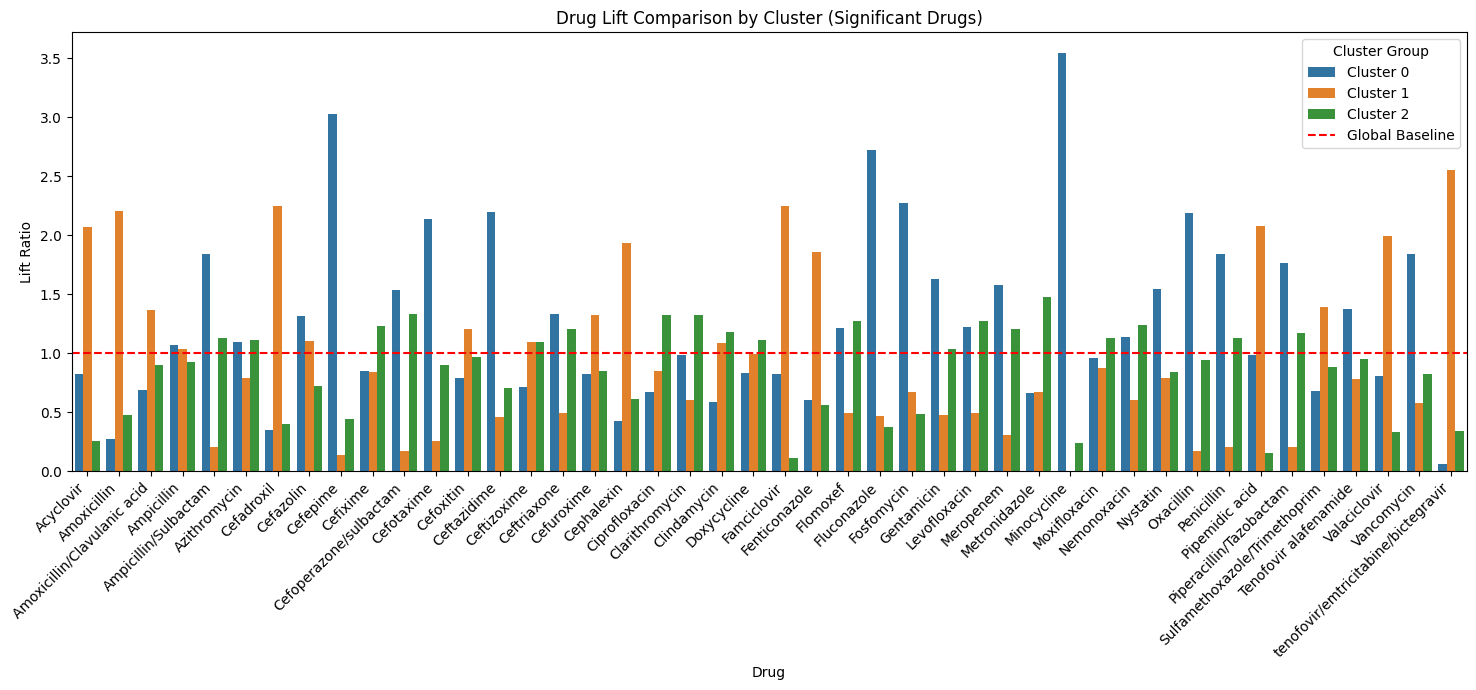

In [128]:
# 1. 整理資料存入 list
lift_records = []
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate)
    
    for drug, val in lift.items():
        lift_records.append({
            'Cluster': f'Cluster {c}',
            'Drug': drug,
            'Lift': val
        })

df_lift_plot = pd.DataFrame(lift_records)

# 2. 繪圖：只挑出 Lift 較顯著的藥物（例如 Lift > 1.5 的藥物）
# 否則藥物太多圖會擠在一起
significant_drugs = df_lift_plot[df_lift_plot['Lift'] > 1.0]['Drug'].unique()
df_filtered = df_lift_plot[df_lift_plot['Drug'].isin(significant_drugs)]

plt.figure(figsize=(15, 7))
sns.barplot(data=df_filtered, x='Drug', y='Lift', hue='Cluster')

# 畫一條紅線代表基準線 (Lift=1)
plt.axhline(1, ls='--', color='red', label='Global Baseline')

plt.title('Drug Lift Comparison by Cluster (Significant Drugs)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Lift Ratio')
plt.legend(title='Cluster Group')
plt.tight_layout()
plt.show()


In [129]:
# 每群抗生素數量
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_num = subset[y_train.columns].sum(axis=1).mean()
    print(drug_num)

cluster 0
1.265743809709495
cluster 1
1.162856715971911
cluster 2
1.3173237753882916


In [130]:
# 挑選關鍵重症指標
severity_indicators = cluster_features

cols_to_show = [c for c in severity_indicators if c in cluster_features]

cluster_summary = X_train.groupby('cluster')[cols_to_show].mean().T
cluster_summary # 0:輕、1:中、2:重

cluster,0,1,2
WBC,-0.627899,-0.037524,0.414772
CRP,-0.206836,-0.041631,0.160036
Lymphocyte,0.926412,-0.165912,-0.435020
Neutrophil Seg.,-0.929738,0.138987,0.458588
Absolute Neutrophil count,-0.849772,0.034235,0.493351
VITALSIGNSBT,-0.111094,-0.496240,0.464891
VITALSIGNSRR,0.419522,-0.251837,-0.055697
VITALSIGNSPR,-0.022624,-0.468483,0.388482
VITALSIGNSGCS,-0.662667,0.291406,0.173052
VITALSIGNSSPO2,-0.410665,0.268885,0.036637


In [131]:
# # PCA 降到 2 維
# pca = PCA(n_components=2)
# X_train_pca = pca.fit_transform(X_train[cluster_features])

# plt.figure(figsize=(10, 7))
# sns.scatterplot(
#     x=X_train_pca[:, 0], 
#     y=X_train_pca[:, 1], 
#     hue=X_train['cluster'], # 根據 GMM 分群上色
#     palette='viridis', 
#     alpha=0.6
# )

# plt.title('GMM Clusters Visualized by PCA')
# plt.xlabel('PCA 1')
# plt.ylabel('PCA 2')
# plt.legend(title='Cluster')
# plt.show()


In [132]:
# cluster prob，並且排序sorted_cluster
cluster_prob_train = gmm.predict_proba(X_train[cluster_features])
cluster_prob_train = cluster_prob_train[:, sorted_cluster]
cluster_prob_test = gmm.predict_proba(X_test[cluster_features])
cluster_prob_test = cluster_prob_test[:, sorted_cluster]

In [133]:
def cluster_prob(df, cluster_prob):
    cluster_df = pd.DataFrame(
        cluster_prob,
        columns=[f'cluster_{i}' for i in range(cluster_prob.shape[1])]
    )
    final_df = pd.concat([df.reset_index(drop=True), cluster_df], axis=1)
    return final_df

X_train = cluster_prob(X_train, cluster_prob_train)
X_test = cluster_prob(X_test, cluster_prob_test)

In [134]:
# X_train = X_train.drop(columns='cluster')
# X_test = X_test.drop(columns='cluster')

In [135]:
X_train

,PT,Ht,Na,CNS,Neutrophil Seg.,AUTOIMMUNE,Absolute Neutrophil count,Creatinine,CHECKITEM29SCORE,CANCER,RBC,CHECKITEM28SCORE,Microscopic WBC level,CRP,CHECKITEM30SCORE,HCO3,VITALSIGNSDBP,CHECKITEM27,SEX,PH,CHECKITEM27SCORE,INFECTIONSITE9,FEVER,INFECTIONSITE2,LIVER,VITALSIGNSSPO2,INJURELEVEL,Miss_INFECTSITE_flag,INFECTIONSITE1,VITALSIGNSPR,VITALSIGNSRR,O2 SAT,Hb,T.Bilirubin,GPT,Microscopic RBC level,APTT,INFECTIONSITE3,HST,Lymphocyte,INFECTIONSITE4,PCO2,CHECKITEM32SCORE,INFECTIONSITE5,PLT,AGE,KIDNEY,VITALSIGNSGCS,INR,DM,CARDIOVASCULAR,BE(ecf),Nitrite level,WBC,CHECKITEM31SCORE,K,StayTime_hours,CHECKITEM28A,VITALSIGNSBT,RESPIRATORY,Leukocyte level,VITALSIGNSSPO2_flag,Hb_flag,WBC_flag,Ht_flag,PLT_flag,Lymphocyte_flag,Neutrophil Seg._flag,Absolute Neutrophil count_flag,Na_flag,K_flag,Creatinine_flag,GPT_flag,CRP_flag,Leukocyte level_flag,Nitrite level_flag,Microscopic RBC level_flag,Microscopic WBC level_flag,PH_flag,CHECKITEM29SCORE_flag,CHECKITEM30SCORE_flag,HST_flag,T.Bilirubin_flag,PT_flag,INR_flag,APTT_flag,PCO2_flag,HCO3_flag,BE(ecf)_flag,O2 SAT_flag,CHECKITEM28A_flag,CHECKITEM27_flag,CHECKITEM27SCORE_flag,CHECKITEM28SCORE_flag,CHECKITEM31SCORE_flag,CHECKITEM32SCORE_flag,cluster,cluster_0,cluster_1,cluster_2
0,-1.0,0.052511,0.081053,0,0.163429,1,0.057779,-0.202066,0.0,0,0.099917,-1.0,-1.0,-0.032642,0.0,-1.0,-0.085530,-3.291258,0,0.053416,1.0,0,0,0,1,0.161943,3.0,1,0,1.096874,-2.243374,0.130374,0.058260,-1.0,-0.117645,-1.0,-0.074608,0,-0.046408,-0.185168,0,-1.0,0.0,0,0.060726,-0.477826,1,0.29944,-1.0,0,0,-0.012563,-1.0,0.004160,-1.0,-0.137486,-0.893499,0.076551,1.912194,1,-1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,2,0.015816,3.465146e-14,0.984184
1,-1.0,-1.008184,-1.408348,1,-0.993369,1,-1.133739,1.171536,0.0,1,-0.507747,0.0,-1.0,2.534740,0.0,-1.0,-1.359735,0.513518,1,0.053416,0.0,0,0,1,1,-0.558609,2.0,0,1,2.386749,0.584216,0.130374,-0.352062,1.5,1.198546,-1.0,-0.074608,0,-0.046408,0.506477,0,-1.0,2.0,0,0.103706,0.578362,1,0.29944,-1.0,1,1,-0.012563,-1.0,-1.221142,1.0,0.015595,0.000291,-0.377078,0.834343,1,-1.0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0.976923,8.590937e-29,0.023077
2,-1.0,-0.456623,1.233945,0,-1.261746,1,-0.356348,0.222612,0.0,0,-0.557687,0.0,-1.0,1.201125,0.0,-1.0,-0.324444,0.028982,1,0.053416,-1.0,0,1,0,0,0.516722,3.0,0,0,-0.527413,0.584216,0.130374,-0.645150,-1.0,-0.807671,-1.0,-0.074608,0,-0.046408,0.810382,0,-1.0,-1.0,1,-0.086778,0.336561,1,0.29944,-1.0,1,1,-0.012563,-1.0,0.020607,-1.0,-0.453250,0.000291,0.969946,-1.839213,1,-1.0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0.865152,1.572375e-05,0.134832
3,-1.0,-1.474889,0.372401,0,-0.567667,0,-1.765122,0.455435,-1.0,0,-0.777663,-1.0,5.0,-1.092052,-1.0,-1.0,-0.404081,0.028982,0,-0.573830,-1.0,0,1,0,1,0.161943,3.0,1,0,-0.240774,-0.456460,0.130374,-1.114090,-1.0,-0.316042,3.0,-0.074608,0,-0.046408,0.139696,0,-1.0,-1.0,0,0.688443,0.027628,1,0.29944,-1.0,0,0,-0.012563,0.0,-1.987077,-1.0,-1.305524,0.000291,0.076551,0.734853,1,4.0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.948381,1.373655e-10,0.051619
4,-1.0,0.498002,0.661646,1,-2.270474,1,-1.508478,-0.503104,-1.0,0,0.130690,-1.0,4.0,-2.013319,-1.0,-1.0,1.029399,0.028982,0,0.637367,-1.0,0,1,0,1,0.516722,3.0,0,0,0.045865,-0.456460,0.130374,0.820288,0.7,-0.425403,8.0,-0.074608,1,-0.046408,2.549973,0,-1.0,-1.0,0,-0.117098,0.514442,1,0.29944,-1.0,0,0,-0.012563,0.0,-0.895636,-1.0,0.165645,1.755781,0.076551,-1.101073,0,4.0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.999996,8.159511e-27,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [136]:
X_train.columns

Index(['PT', 'Ht', 'Na', 'CNS', 'Neutrophil Seg.', 'AUTOIMMUNE',
       'Absolute Neutrophil count', 'Creatinine', 'CHECKITEM29SCORE', 'CANCER',
       'RBC', 'CHECKITEM28SCORE', 'Microscopic WBC level', 'CRP',
       'CHECKITEM30SCORE', 'HCO3', 'VITALSIGNSDBP', 'CHECKITEM27', 'SEX', 'PH',
       'CHECKITEM27SCORE', 'INFECTIONSITE9', 'FEVER', 'INFECTIONSITE2',
       'LIVER', 'VITALSIGNSSPO2', 'INJURELEVEL', 'Miss_INFECTSITE_flag',
       'INFECTIONSITE1', 'VITALSIGNSPR', 'VITALSIGNSRR', 'O2 SAT', 'Hb',
       'T.Bilirubin', 'GPT', 'Microscopic RBC level', 'APTT', 'INFECTIONSITE3',
       'HST', 'Lymphocyte', 'INFECTIONSITE4', 'PCO2', 'CHECKITEM32SCORE',
       'INFECTIONSITE5', 'PLT', 'AGE', 'KIDNEY', 'VITALSIGNSGCS', 'INR', 'DM',
       'CARDIOVASCULAR', 'BE(ecf)', 'Nitrite level', 'WBC', 'CHECKITEM31SCORE',
       'K', 'StayTime_hours', 'CHECKITEM28A', 'VITALSIGNSBT', 'RESPIRATORY',
       'Leukocyte level', 'VITALSIGNSSPO2_flag', 'Hb_flag', 'WBC_flag',
       'Ht_flag', 'PLT_flag',

In [137]:
base_model_cv = XGBClassifier(n_estimators=100,
                              max_depth=5,
                              learning_rate=0.05,
                              subsample=0.8,
                              colsample_bytree=0.8,
                              eval_metric='logloss',
                              gamma=0,
                              reg_alpha=2,
                              reg_lambda=0.0,
                              min_child_weight=1,
                              scale_pos_weight=3,
                              random_state =123,
                              n_jobs=-1
    )

In [138]:
kf = KFold(n_splits=5, shuffle=True, random_state=123)

num_labels = y_train.shape[1]
f1_scores = np.zeros(num_labels)

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = MultiOutputClassifier(base_model_cv)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    for i in range(num_labels):
        f1_scores[i] += f1_score(y_val.iloc[:, i], y_pred[:, i], zero_division=0)

f1_scores /= kf.get_n_splits()

In [139]:
# y_train.columns, f1_scores

In [140]:
selected_labels = [
    col for col, f1 in zip(y_train.columns, f1_scores)
    if f1 >= 0.05  # 或 0.1
]
print(selected_labels)

['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin', 'Cefazolin', 'Cefepime', 'Cefixime', 'Cefoperazone/sulbactam', 'Cefotaxime', 'Ceftriaxone', 'Cefuroxime', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin', 'Metronidazole', 'Nemonoxacin', 'Piperacillin/Tazobactam', 'tenofovir/emtricitabine/bictegravir']


In [60]:
selected_labels = ['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin', 'Cefazolin', 'Cefepime', 
                   'Cefixime', 'Cefoperazone/sulbactam', 'Ceftriaxone', 'Cefuroxime', 'Cefotaxime', 
                   'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin', 'Levofloxacin', 'Metronidazole', 
                   'Nemonoxacin', 'Piperacillin/Tazobactam', 'tenofovir/emtricitabine/bictegravir'] # 'Cephalexin',

In [141]:
# 1. 重新過濾 y_train
y_train = y_train[selected_labels]

# 2. y_test 同步過濾
y_test = y_test[selected_labels]

print(f"保留後的數量: {len(selected_labels)}")

保留後的數量: 18


In [62]:
# 1. 計算 mask，並確保它與 y_train 具有相同的索引
common_idx = X_train.index.intersection(y_train.index)

X_train = X_train.loc[common_idx]
y_train = y_train.loc[common_idx]

keep_samples_mask = (y_train.sum(axis=1) > 0)
print(len(X_train), len(keep_samples_mask))
print(X_train.index.equals(y_train.index)) # 應該要回傳 True

# 2. 使用 .loc 進行過濾，這是最安全的方式
common_idx_test = X_test.index.intersection(y_test.index)

X_test = X_test.loc[common_idx_test]
y_test = y_test.loc[common_idx_test]

X_train = X_train.loc[keep_samples_mask]
y_train = y_train.loc[keep_samples_mask]

# 3. 對測試集也做同樣處理
keep_test_mask = (y_test.sum(axis=1) > 0)
X_test = X_test.loc[keep_test_mask]
y_test = y_test.loc[keep_test_mask]


20067 20067
True


In [63]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18261, 100), (4555, 100), (18261, 19), (4555, 19))

In [64]:
base_model = XGBClassifier(n_estimators=500,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=2,
                           reg_lambda=0.0,
                           min_child_weight=1,
                           scale_pos_weight=3,
                           random_state =123,
                           n_jobs=-1
    )

multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, y_train) # sample_weight=sample_weight

,estimator,"XGBClassifier...ree=None, ...)"
,n_jobs,None
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [65]:
X_train

,PT,Ht,Na,CNS,Neutrophil Seg.,AUTOIMMUNE,Absolute Neutrophil count,Creatinine,CHECKITEM29SCORE,CANCER,RBC,CHECKITEM28SCORE,Microscopic WBC level,CRP,CHECKITEM30SCORE,HCO3,VITALSIGNSDBP,CHECKITEM27,SEX,PH,CHECKITEM27SCORE,INFECTIONSITE9,FEVER,INFECTIONSITE2,LIVER,VITALSIGNSSPO2,INJURELEVEL,Miss_INFECTSITE_flag,INFECTIONSITE1,VITALSIGNSPR,VITALSIGNSRR,O2 SAT,Hb,T.Bilirubin,GPT,Microscopic RBC level,APTT,INFECTIONSITE3,HST,Lymphocyte,INFECTIONSITE4,PCO2,CHECKITEM32SCORE,INFECTIONSITE5,PLT,AGE,KIDNEY,VITALSIGNSGCS,INR,DM,CARDIOVASCULAR,BE(ecf),Nitrite level,WBC,CHECKITEM31SCORE,K,StayTime_hours,CHECKITEM28A,VITALSIGNSBT,RESPIRATORY,Leukocyte level,VITALSIGNSSPO2_flag,Hb_flag,WBC_flag,Ht_flag,PLT_flag,Lymphocyte_flag,Neutrophil Seg._flag,Absolute Neutrophil count_flag,Na_flag,K_flag,Creatinine_flag,GPT_flag,CRP_flag,Leukocyte level_flag,Nitrite level_flag,Microscopic RBC level_flag,Microscopic WBC level_flag,PH_flag,CHECKITEM29SCORE_flag,CHECKITEM30SCORE_flag,HST_flag,T.Bilirubin_flag,PT_flag,INR_flag,APTT_flag,PCO2_flag,HCO3_flag,BE(ecf)_flag,O2 SAT_flag,CHECKITEM28A_flag,CHECKITEM27_flag,CHECKITEM27SCORE_flag,CHECKITEM28SCORE_flag,CHECKITEM31SCORE_flag,CHECKITEM32SCORE_flag,cluster,cluster_0,cluster_1,cluster_2
1,9.9,-0.566085,0.083914,0,0.162280,0,0.056636,-0.211256,-1.0,0,-0.333354,-1.0,2.0,-0.034039,-1.0,-1.0,-0.323668,0.027838,0,1.664860,-1.0,0,1,0,0,0.160148,2.0,1,0,-0.671440,-0.455081,0.131854,-0.809710,-1.0,-0.123601,1.0,-1.651193,0,-0.054464,-0.186271,0,-1.0,-1.0,0,-1.237691,-0.206401,1,0.299068,0.86,0,0,-0.015428,0.0,-0.725559,-1.0,-0.138060,-0.001928,0.072955,-0.481510,0,3.0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0.000002,9.997344e-01,2.640055e-04
2,-1.0,0.040726,0.083914,0,0.162280,0,0.056636,-0.211256,-1.0,0,0.104217,-1.0,-1.0,-0.034039,-1.0,-1.0,0.389390,0.027838,0,0.058475,-1.0,0,1,0,0,0.513397,3.0,1,0,-0.100684,-0.455081,0.131854,0.060003,-1.0,-0.123601,-1.0,-0.073475,0,-0.054464,-0.186271,0,-1.0,-1.0,0,0.059348,-0.928178,0,0.299068,-1.00,0,0,-0.015428,-1.0,-0.004139,-1.0,-0.138060,-0.001928,0.072955,-1.103975,0,-1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.000001,9.996503e-01,3.481642e-04
3,-1.0,0.040726,0.083914,0,0.162280,1,0.056636,-0.211256,-1.0,0,0.104217,-1.0,-1.0,-0.034039,-1.0,-1.0,-0.719812,0.027838,0,0.058475,-1.0,0,1,0,1,-4.384743,1.0,0,1,-1.337322,2.384570,0.131854,0.060003,-1.0,-0.123601,-1.0,-0.073475,0,-0.054464,-0.186271,0,-1.0,-1.0,0,0.059348,0.141794,0,0.299068,-1.00,0,0,-0.015428,-1.0,-0.004139,-1.0,-0.138060,0.596233,0.072955,-1.843035,0,-1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.999995,3.611365e-48,4.652381e-06
4,-1.0,-0.921802,0.948170,1,1.385727,1,1.043878,-0.298853,0.0,1,-0.694495,0.0,5.0,0.844165,0.0,22.7,-0.085982,-0.324513,0,-0.554671,0.0,0,0,0,1,0.863095,2.0,0,0,0.137131,1.521804,-0.141945,-1.099615,-1.0,-0.034401,2.0,-0.073475,1,-0.054464,-1.141594,0,35.0,0.0,0,-0.389407,0.652267,1,0.299068,-1.00,0,1,-0.065210,1.0,0.866585,-1.0,-0.138060,-0.001928,1.422266,2.774231,1,4.0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,2,0.027180,2.271215e-29,9.728204e-01
5,-1.0,0.040726,0.083914,0,0.162280,1,0.056636,-0.211256,-1.0,0,0.104217,-1.0,-1.0,-0.034039,-1.0,-1.0,-0.402897,0.027838,1,0.058475,-1.0,0,1,0,0,0.160148,3.0,1,0,-1.194633,0.580502,0.131854,0.060003,-1.0,-0.123601,-1.0,-0.073475,0,-0.054464,-0.186271,0,-1.0,-1.0,0,0.059348,-0.989242,0,0.299068,-1.00,0,0,-0.015428,-1.0,-0.004139,-1.0,-0.138060,1.403945,0.072955,-0.173983,1,-1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.000039,9.943862e-01,5.575080e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [66]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.832422436819396
0.8988267432200345


In [67]:
# # # 原始機率
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])
y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

# 計算每種抗生素的使用頻率
drug_freq = y_train.mean(axis=0).values
drug_freq = np.clip(drug_freq, 1e-6, None) #避免除以0

# ############################
# # 用y_train去計算f1，或用cv

# # 計算每種抗生素權重(F1/recall)
# drug_weight = []
# ############################
# # 1. 用y_train
# # for i, col in enumerate(y_train.columns):
# #     # score = 1 / (f1_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
# #     score = 1 / (recall_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
# #     drug_weight.append(score)
    
# # drug_weight = np.clip(drug_weight, 1e-6, None)
# ###########################
# # 2. 用cv
# # 對每個sub model跑cv
# for i, col in enumerate(y_train.columns):
#     #取得每個子模型
#     model = multi_model.estimators_[i]
#     #5-fold
#     cv_predicts = cross_val_predict(model, X_train, y_train.iloc[:, i], cv=5, n_jobs=-1)
#     #真實的recall
#     recall = recall_score(y_train.iloc[:, i], cv_predicts, average='binary')
#     #轉為權重
#     weight = 1 / (recall + 1e-6)
#     drug_weight.append(weight)
    
# drug_weight = np.array(drug_weight)
# ###########################

# #  normalize
# drug_weight = drug_weight / drug_weight.mean()


In [68]:
drug_weight = []

for i in range(y_train.shape[1]):
    base_model = XGBClassifier(
                           n_estimators=500,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=2,
                           reg_lambda=0.0,
                           min_child_weight=1,
                           scale_pos_weight=3,
                           random_state =123,
                           n_jobs=-1
    )

    cv_pred = cross_val_predict(
        base_model,
        X_train,
        y_train.iloc[:, i],
        cv=5,
        method='predict',
        n_jobs=-1
    )

    recall = recall_score(y_train.iloc[:, i], cv_pred)
    
    weight = (1 / (recall + 0.1)) ** 0.5
    drug_weight.append(weight)
    
drug_weight = np.array(drug_weight)
drug_weight = drug_weight / drug_weight.mean()

In [69]:
alpha = 0.05 # penalty
belta = 0.05

# adjusted_scores = y_prob_list / (drug_freq ** alpha)
# adjusted_scores = np.log(y_prob_list + 1e-6) - np.log(drug_freq ** alpha)
adjusted_scores = (np.log(y_prob_list + 1e-6)+ belta * np.log(drug_weight)- alpha * np.log(drug_freq))
# adjusted_scores = y_prob_list * drug_weight ** belta - alpha * np.log(drug_freq)

In [70]:
# # adjusted_scores Softmax
exp_scores = np.exp(adjusted_scores)
scores_softmax = exp_scores / exp_scores.sum(axis=1, keepdims=True)

In [71]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.5217633928571429
0.381522800364136


In [72]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

0.46121112330772046

In [73]:
hamming_loss(y_test, y_pred)

0.05941417759547057

In [74]:
# target_names = y_train.columns

# for i, col in enumerate(target_names):
#     print(f'-- {col} --')
#     print(classification_report(y_train.iloc[:, i], y_pred_train[:, i]))

In [75]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, scores, k=3):

    topk = np.argsort(scores, axis=1)[:, ::-1][:, :k]  # 排序

    APs = []

    for i in range(len(y_true)):
        actual = np.where(y_true[i] == 1)[0]

        if len(actual) == 0:
            continue

        hits = 0
        score = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)

        APs.append(score / min(len(actual), k))

    return np.mean(APs)


################################

k=5
hitk = hit_rate_at_k(y_test.values, adjusted_scores, k=k)
print(f"Hit@{k}: {hitk}")
precisionk = precision_at_k(y_test.values, adjusted_scores, k=k)
print(f"precision@{k}: {precisionk}")
recall_k = recall_at_k(y_test.values, adjusted_scores, k=k)
print(f"Recall@{k}: {recall_k}")
map_k = map_at_k(y_test.values, adjusted_scores, k=k)
print(f"MAP@{k}: {map_k}")

Hit@5: 0.9315038419319429
precision@5: 0.22239297475303046
Recall@5: 0.9032894255397
MAP@5: 0.676033967557019


In [76]:
# topk_counts = np.zeros(num_labels)

# topk_idx = np.argsort(y_prob_list, axis=1)[:, -3:]

# for i in range(len(topk_idx)):
#     for idx in topk_idx[i]:
#         topk_counts[idx] += 1

In [77]:
hit1 = hit_rate_at_k(y_test.values, adjusted_scores, k=1)
hit1

0.5670691547749726

In [78]:
drug_names = y_train.columns


def show_top3_prediction(patient_idx, proba_matrix, y_true, drug_names, k=3):
    #預測
    probs = proba_matrix[patient_idx]
    topk_idx = np.argsort(probs)[-k:][::-1]

    #實際
    actual_idx = np.where(y_true[patient_idx] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs if actual_drugs else '無'}")
    print("\n推薦藥物:")
    for rank, idx in enumerate(topk_idx, 1):
        print(f"{rank}. {drug_names[idx]} (Score: {probs[idx]:.4f})")
    print("="*50)

for i in range(10):
    show_top3_prediction(i, scores_softmax, y_test.values, drug_names, k=6)

實際給藥: ['Cefuroxime']

推薦藥物:
1. Amoxicillin/Clavulanic acid (Score: 0.3985)
2. Cefuroxime (Score: 0.1605)
3. Cefixime (Score: 0.1391)
4. Azithromycin (Score: 0.1244)
5. Ciprofloxacin (Score: 0.0775)
6. Levofloxacin (Score: 0.0474)
實際給藥: ['Azithromycin', 'Cefoperazone/sulbactam']

推薦藥物:
1. Flomoxef (Score: 0.3517)
2. Piperacillin/Tazobactam (Score: 0.1680)
3. Cefoperazone/sulbactam (Score: 0.1489)
4. Amoxicillin/Clavulanic acid (Score: 0.0694)
5. Azithromycin (Score: 0.0681)
6. Levofloxacin (Score: 0.0654)
實際給藥: ['Cefixime', 'Metronidazole']

推薦藥物:
1. Amoxicillin/Clavulanic acid (Score: 0.3022)
2. Ciprofloxacin (Score: 0.2850)
3. Cefixime (Score: 0.1914)
4. Azithromycin (Score: 0.1452)
5. Levofloxacin (Score: 0.0448)
6. Cefuroxime (Score: 0.0129)
實際給藥: ['Cefixime']

推薦藥物:
1. Ciprofloxacin (Score: 0.6376)
2. Cefixime (Score: 0.1589)
3. Cefuroxime (Score: 0.1352)
4. Amoxicillin/Clavulanic acid (Score: 0.0475)
5. Metronidazole (Score: 0.0080)
6. Levofloxacin (Score: 0.0041)
實際給藥: ['Ciproflo

In [79]:
def explain_topk_patient(i, X, y_true, multi_model, scores, drug_names, k=3):
    x = X.iloc[i:i+1]
    probs = scores[i]

    topk_idx = np.argsort(probs)[-k:][::-1]

    actual_idx = np.where(y_true.iloc[i] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs}")
    print("="*60)
    cluster_columns = ['cluster_0', 'cluster_1', 'cluster_2']
    cluster_prob = X.iloc[i][cluster_columns].values
    cluster_map = {0:'表現較嚴重', 1:'表現中等', 2:'表現較輕微'}
    
    # # 主要傾向分布
    print("病人嚴重傾向機率分布:")
    for idx, prob in enumerate(cluster_prob):
        # 格式化為百分比，方便閱讀
        print(f"  - {cluster_map[idx]:<6}: {prob*100:>5.1f}%")
    
    # # 主要傾向
    # cluster_label = np.argmax(cluster_prob)
    # print(f"\n病人嚴重傾向: {cluster_map[cluster_label]}")

    for rank, idx in enumerate(topk_idx, 1):
        model = multi_model.estimators_[idx]
        # 0.令
        booster = model.get_booster()
        
        # 1. 將 pandas 的 x 轉換為 XGBoost 專用的 DMatrix
        dtrain = xgb.DMatrix(x)

        # 2. 執行預測取得 SHAP 值 (pred_contribs=True)
        # 這會回傳一個 numpy array，形狀為 (1, 特徵數 + 1)
        shap_matrix = booster.predict(dtrain, pred_contribs=True)

        # 3. 拿掉最後一欄 (Bias/Intercept)，只留特徵貢獻度
        shap_values = shap_matrix[:, :-1]
    ###############   
        # 4. 整理成 Series (注意：這裡不需要再呼叫 explainer.shap_values 了)
        # all_contrib = pd.Series(shap_values[0],index=X.columns)

        # 5. 篩選絕對值大於 0.1 的特徵 (即 > 0.1 或 < -0.1)
        # contrib = all_contrib[all_contrib.abs() > 0.1].sort_values(key=abs, ascending=False)
    ###############    
        # 5. 分出>0和<0兩部分，分別取平均，然後篩選出正的是大於平均、負的是小於平均的特徵，最後再依照其對值排序
        # 5.1. 整理成 Series
        all_contrib = pd.Series(shap_values[0], index=X.columns)
        # print(shap_values)

        # 5.2. 分離正負貢獻部分
        pos_part = all_contrib[all_contrib > 0]
        neg_part = all_contrib[all_contrib < 0]

        # 5.3. 分別計算平均並篩選 (加入 if 判斷避免該藥物完全沒有正/負向特徵時報錯)
        pos_contrib_filter = pd.Series(dtype=float)
        if not pos_part.empty:
            pos_mean = pos_part.mean()
            # 篩選出高於平均的正向特徵
            pos_contrib_filter = pos_part[pos_part >= pos_mean]

        neg_contrib_filter = pd.Series(dtype=float)
        if not neg_part.empty:
            neg_mean = neg_part.mean()
            # 篩選出低於平均 (即絕對值更大) 的負向特徵
            neg_contrib_filter = neg_part[neg_part <= neg_mean]

        # 5.4. 合併兩部分
        contrib = pd.concat([pos_contrib_filter, neg_contrib_filter])

        # 5.5. 移除群聚標籤
        contrib = contrib.drop(labels=['cluster_0', 'cluster_1', 'cluster_2', 'Miss_INFECTSITE_flag', 'StayTime_hours',
                                       'VITALSIGNSSPO2_flag', 'Hb_flag', 'WBC_flag', 'Ht_flag', 'PLT_flag', 'Lymphocyte_flag', 
                                       'Neutrophil Seg._flag', 'Absolute Neutrophil count_flag', 'Na_flag', 'K_flag', 'PLT_flag', 
                                       'Creatinine_flag', 'GPT_flag', 'CRP_flag', 'Leukocyte level_flag', 'Nitrite level_flag',
                                       'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag', 'CHECKITEM29SCORE_flag',
                                       'CHECKITEM30SCORE_flag', 'HST_flag', 'T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag',
                                       'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag', 'O2 SAT_flag', 'CHECKITEM28A_flag',
                                       'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 'CHECKITEM31SCORE_flag',
                                       'CHECKITEM32SCORE_flag', 'INJURELEVEL'], 
                               errors='ignore')
        
        # 5.6. 並依絕對值排序，如果篩選後特徵太多，最多只顯示前 10 個
        contrib = contrib.sort_values(key=abs, ascending=False).head(10)

        print(f"\n{rank}: {drug_names[idx]}")
        print(f"\nScore: {probs[idx]:.4f}")
        print("\n主要影響特徵 and Shap值:")
        total_impact = contrib.abs().sum()
        for feat, val in contrib.items():
            pct = (val / total_impact) * 100
            direction = "+" if val > 0 else "-" 
            print(f"{feat:<15}: {direction} {abs(pct):.1f}%")
            
        # print(contrib)
        print("-"*40)

In [80]:
# explain_topk_patient(0, X_test, y_test, multi_model, scores_softmax, y_test.columns, k=5)

In [81]:
for i in range(10):
    explain = explain_topk_patient(i, X_test, y_test, multi_model, scores_softmax, y_test.columns, k=5)

實際給藥: ['Cefuroxime']
病人嚴重傾向機率分布:
  - 表現較嚴重 :   0.6%
  - 表現中等  :  71.0%
  - 表現較輕微 :  28.5%

1: Amoxicillin/Clavulanic acid

Score: 0.3985

主要影響特徵 and Shap值:
KIDNEY         : - 19.5%
INFECTIONSITE2 : + 14.4%
VITALSIGNSRR   : + 10.4%
VITALSIGNSBT   : - 9.8%
INFECTIONSITE5 : - 8.8%
SEX            : - 8.6%
CHECKITEM27    : + 8.0%
Microscopic WBC level: + 7.4%
PT             : + 6.7%
Nitrite level  : + 6.3%
----------------------------------------

2: Cefuroxime

Score: 0.1605

主要影響特徵 and Shap值:
CRP            : - 34.0%
KIDNEY         : + 14.6%
SEX            : + 12.1%
INFECTIONSITE1 : + 11.9%
Microscopic WBC level: - 5.1%
VITALSIGNSSPO2 : + 4.7%
Leukocyte level: - 4.7%
VITALSIGNSBT   : + 4.7%
AGE            : - 4.2%
RESPIRATORY    : + 4.1%
----------------------------------------

3: Cefixime

Score: 0.1391

主要影響特徵 and Shap值:
AGE            : - 25.6%
KIDNEY         : + 13.9%
PH             : + 9.5%
Microscopic WBC level: - 9.1%
INFECTIONSITE1 : + 8.6%
SEX            : + 7.6%
T.Bilirubin    